# Homework 2: Machine Learning for Regression

In [9]:
import pandas as pd
import matplotlib_inline as plt
import numpy as np

In [42]:
df = pd.read_csv('/content/car_fuel_efficiency.csv')

df

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,NaN,15.101802
9700,180,NaN,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,0.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,-1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


## Preparing the dataset

In [39]:
cols = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']

df = df[cols]

df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


## EDA

<Axes: >

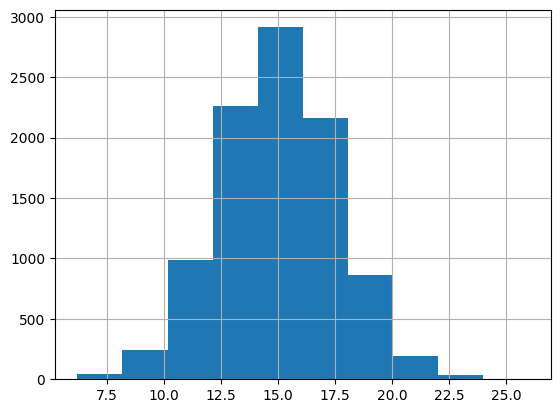

In [5]:
df['fuel_efficiency_mpg'].hist()

In [6]:
df["fuel_efficiency_mpg"].skew()

np.float64(-0.012062219273507929)

Approximately symmetric distribution, but with a slight left skew (negative skewness).

## Q1

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   horsepower           8996 non-null   float64
 2   vehicle_weight       9704 non-null   float64
 3   model_year           9704 non-null   int64  
 4   fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 379.2 KB


## Q2

In [8]:
df['horsepower'].describe()

,horsepower
count,8996.000000
mean,149.657292
std,29.879555
min,37.000000
25%,130.000000
50%,149.000000
75%,170.000000
max,271.000000


Prepare and split the dataset
Shuffle the dataset (the filtered one you created above), use seed 42.
Split your data in train/val/test sets, with 60%/20%/20% distribution.
Use the same code as in the lectures

In [35]:
import pandas as pd
import numpy as np

np.random.seed(42)
indices = np.arange(len(df))
np.random.shuffle(indices)

df_shuffled = df.iloc[indices].reset_index(drop=True)

n= len(df)
n_train = int(0.6 * n)
n_val   = int(0.2 * n)
n_test  = n - n_train - n_val

train_df = df_shuffled.iloc[:n_train]
val_df   = df_shuffled.iloc[n_train:n_train + n_val]
test_df  = df_shuffled.iloc[n_train + n_val:]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 5822 | Val: 1940 | Test: 1942


## Q3

In [48]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [51]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

Fill missing horsepower with 0

In [52]:
train_0 = train_df.copy()
val_0 = val_df.copy()

train_0['horsepower'] = train_0['horsepower'].fillna(0)
val_0['horsepower'] = val_0['horsepower'].fillna(0)

X_train_0 = train_0[cols[:-1]].values
y_train_0 = train_0['fuel_efficiency_mpg'].values

X_val_0 = val_0[cols[:-1]].values
y_val_0 = val_0['fuel_efficiency_mpg'].values

w0_0, w_0 = train_linear_regression(X_train_0, y_train_0)
y_pred_0 = w0_0 + X_val_0.dot(w_0)
rmse_0 = rmse(y_val_0, y_pred_0)
print("RMSE (fill 0):", round(rmse_0, 2))

RMSE (fill 0): 0.52


Fill missing horsepower with MEAN (train only)

In [53]:
train_mean = train_df.copy()
val_mean = val_df.copy()

horsepower_mean = train_mean['horsepower'].mean()

train_mean['horsepower'] = train_mean['horsepower'].fillna(horsepower_mean)
val_mean['horsepower'] = val_mean['horsepower'].fillna(horsepower_mean)

X_train_m = train_mean[cols[:-1]].values
y_train_m = train_mean['fuel_efficiency_mpg'].values

X_val_m = val_mean[cols[:-1]].values
y_val_m = val_mean['fuel_efficiency_mpg'].values

w0_m, w_m = train_linear_regression(X_train_m, y_train_m)
y_pred_m = w0_m + X_val_m.dot(w_m)
rmse_m = rmse(y_val_m, y_pred_m)
print("RMSE (fill mean):", round(rmse_m, 2))


RMSE (fill mean): 0.46


Compare results

In [57]:
if rmse_m > rmse_0:
    print(f"✅ Filling with MEAN gives better RMSE ({round(rmse_m, 2)} < {round(rmse_0, 2)})")
else:
    print(f"✅ Filling with 0 gives better RMSE ({round(rmse_0, 2)} > {round(rmse_m, 2)})")

✅ Filling with 0 gives better RMSE (0.52 > 0.46)


## Q4

In [59]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [61]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

best_rmse = np.inf
best_r = None

for r in r_values:
    w0_r, w_r = train_linear_regression_reg(X_train_0, y_train_0, r=r)

    y_pred_r = w0_r + X_val_m.dot(w_r)

    # RMSE
    rmse_r = round(np.sqrt(((y_val_m - y_pred_r)**2).mean()), 2)
    print(f"r={r}: RMSE={rmse_r}")

    if rmse_r < best_rmse or (rmse_r == best_rmse and r < best_r):
        best_rmse = rmse_r
        best_r = r

print(f"\n✅ Best r: {best_r} with RMSE={best_rmse}")



r=0: RMSE=0.5
r=0.01: RMSE=0.5
r=0.1: RMSE=0.5
r=1: RMSE=0.51
r=5: RMSE=0.51
r=10: RMSE=0.51
r=100: RMSE=0.51

✅ Best r: 0 with RMSE=0.5


## Q5

In [63]:
import numpy as np

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

rmse_scores = []

for seed in seeds:
    np.random.seed(seed)
    indices = np.arange(len(df))
    np.random.shuffle(indices)
    df_shuffled = df.iloc[indices].reset_index(drop=True)

    n = len(df_shuffled)
    n_train = int(0.6 * n)
    n_val   = int(0.2 * n)
    n_test  = n - n_train - n_val

    train_df = df_shuffled.iloc[:n_train]
    val_df   = df_shuffled.iloc[n_train:n_train+n_val]

    train_df_filled = train_df.copy()
    val_df_filled = val_df.copy()
    train_df_filled['horsepower'] = train_df_filled['horsepower'].fillna(0)
    val_df_filled['horsepower'] = val_df_filled['horsepower'].fillna(0)

    X_train = train_df_filled[cols[:-1]].values
    y_train = train_df_filled['fuel_efficiency_mpg'].values
    X_val = val_df_filled[cols[:-1]].values
    y_val = val_df_filled['fuel_efficiency_mpg'].values

    w0, w = train_linear_regression(X_train, y_train)

    y_pred = w0 + X_val.dot(w)
    rmse = np.sqrt(((y_val - y_pred)**2).mean())

    rmse_scores.append(rmse)

std_rmse = round(np.std(rmse_scores), 3)
print("Standard deviation of RMSE scores:", std_rmse)


Standard deviation of RMSE scores: 0.007


# Q6

In [65]:
import numpy as np

np.random.seed(9)
indices = np.arange(len(df))
np.random.shuffle(indices)
df_shuffled = df.iloc[indices].reset_index(drop=True)

n = len(df_shuffled)
n_train = int(0.6 * n)
n_val   = int(0.2 * n)
n_test  = n - n_train - n_val

train_df = df_shuffled.iloc[:n_train]
val_df   = df_shuffled.iloc[n_train:n_train+n_val]
test_df  = df_shuffled.iloc[n_train+n_val:]

train_val_df = pd.concat([train_df, val_df]).reset_index(drop=True)

train_val_df_filled = train_val_df.copy()
test_df_filled = test_df.copy()

train_val_df_filled['horsepower'] = train_val_df_filled['horsepower'].fillna(0)
test_df_filled['horsepower'] = test_df_filled['horsepower'].fillna(0)

X_train_val = train_val_df_filled[cols[:-1]].values
y_train_val = train_val_df_filled['fuel_efficiency_mpg'].values

X_test = test_df_filled[cols[:-1]].values
y_test = test_df_filled['fuel_efficiency_mpg'].values

r = 0.001
w0, w = train_linear_regression_reg(X_train_val, y_train_val, r=r)

y_pred_test = w0 + X_test.dot(w)
rmse_test = round(np.sqrt(((y_test - y_pred_test)**2).mean()), 2)
print("RMSE on test dataset:", rmse_test)


RMSE on test dataset: 0.52
